<a href="https://colab.research.google.com/github/URahul11/Customer_chrun_ANN/blob/main/Customer_chrun_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, accuracy_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# --- Option A: Upload directly in Colab ---
from google.colab import files
uploaded = files.upload()  # select customer_churn_dataset.csv when prompted

# --- Option B: If already mounted from Google Drive, comment Option A out and use: ---
# from google.colab import drive
# drive.mount('/content/drive')
# path = '/content/drive/MyDrive/customer_churn_dataset.csv'

df = pd.read_csv('/content/customer_churn_dataset - customer_churn_dataset.csv')
print('Shape:', df.shape)
df.head()

Saving customer_churn_dataset - customer_churn_dataset.csv to customer_churn_dataset - customer_churn_dataset (1).csv
Shape: (2000, 16)


,CustomerID,Gender,SeniorCitizen,Age,Tenure,ContractType,InternetService,TechSupport,OnlineSecurity,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumComplaints,SatisfactionScore,Churn
0,CUST100000,Male,0,54,16,Month-to-Month,DSL,No,No,No,Mailed Check,60.56,982.44,0,3.7,1
1,CUST100001,Female,0,49,9,Month-to-Month,Fiber Optic,Yes,No,Yes,Bank Transfer,86.60,842.55,5,5.7,1
2,CUST100002,Male,1,49,7,One Year,DSL,Yes,Yes,Yes,Electronic Check,37.84,258.88,2,8.7,0
3,CUST100003,Male,0,23,14,Two Year,DSL,Yes,No,Yes,Credit Card,61.15,883.27,0,7.5,0
4,CUST100004,Male,0,56,3,Two Year,Fiber Optic,Yes,No,Yes,Electronic Check,98.89,251.26,1,8.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2000 non-null   object 
 1   Gender             2000 non-null   object 
 2   SeniorCitizen      2000 non-null   int64  
 3   Age                2000 non-null   int64  
 4   Tenure             2000 non-null   int64  
 5   ContractType       2000 non-null   object 
 6   InternetService    2000 non-null   object 
 7   TechSupport        2000 non-null   object 
 8   OnlineSecurity     2000 non-null   object 
 9   PaperlessBilling   2000 non-null   object 
 10  PaymentMethod      2000 non-null   object 
 11  MonthlyCharges     2000 non-null   float64
 12  TotalCharges       1985 non-null   float64
 13  NumComplaints      2000 non-null   int64  
 14  SatisfactionScore  2000 non-null   float64
 15  Churn              2000 non-null   int64  
dtypes: float64(3), int64(5),

In [ ]:
df.describe(include='all')

,CustomerID,Gender,SeniorCitizen,Age,Tenure,ContractType,InternetService,TechSupport,OnlineSecurity,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumComplaints,SatisfactionScore,Churn
count,2000,2000,2000.000000,2000.000000,2000.0000,2000,2000,2000,2000,2000,2000,2000.000000,1985.000000,2000.000000,2000.000000,2000.000000
unique,2000,2,NaN,NaN,NaN,3,3,2,2,2,4,NaN,NaN,NaN,NaN,NaN
top,CUST101983,Male,NaN,NaN,NaN,Month-to-Month,Fiber Optic,No,No,Yes,Electronic Check,NaN,NaN,NaN,NaN,NaN
freq,1,1016,NaN,NaN,NaN,1145,902,1208,1288,1166,637,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.163500,40.430500,22.0230,NaN,NaN,NaN,NaN,NaN,NaN,63.226470,1399.710892,1.545500,6.144600,0.313500
std,NaN,NaN,0.369914,12.604269,20.2039,NaN,NaN,NaN,NaN,NaN,NaN,25.516166,1502.250242,1.154381,1.329385,0.464032
min,NaN,NaN,0.000000,18.000000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,0.000000,0.000000,1.200000,0.000000
25%,NaN,NaN,0.000000,31.000000,6.0000,NaN,NaN,NaN,NaN,NaN,NaN,45.302500,316.940000,1.000000,5.200000,0.000000
50%,NaN,NaN,0.000000,40.000000,16.0000,NaN,NaN,NaN,NaN,NaN,NaN,65.950000,866.140000,1.000000,6.100000,0.000000
75%,NaN,NaN,0.000000,49.000000,32.0000,NaN,NaN,NaN,NaN,NaN,NaN,84.337500,1988.230000,2.000000,7.100000,1.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Age,0
Tenure,0
ContractType,0
InternetService,0
TechSupport,0
OnlineSecurity,0
PaperlessBilling,0


/tmp/ipykernel_549/2290499439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


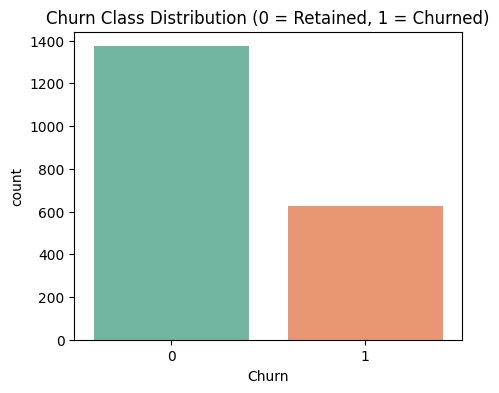

Churn
0    0.6865
1    0.3135
Name: proportion, dtype: float64


In [ ]:
# Target class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Class Distribution (0 = Retained, 1 = Churned)')
plt.show()

print(df['Churn'].value_counts(normalize=True).rename('proportion'))

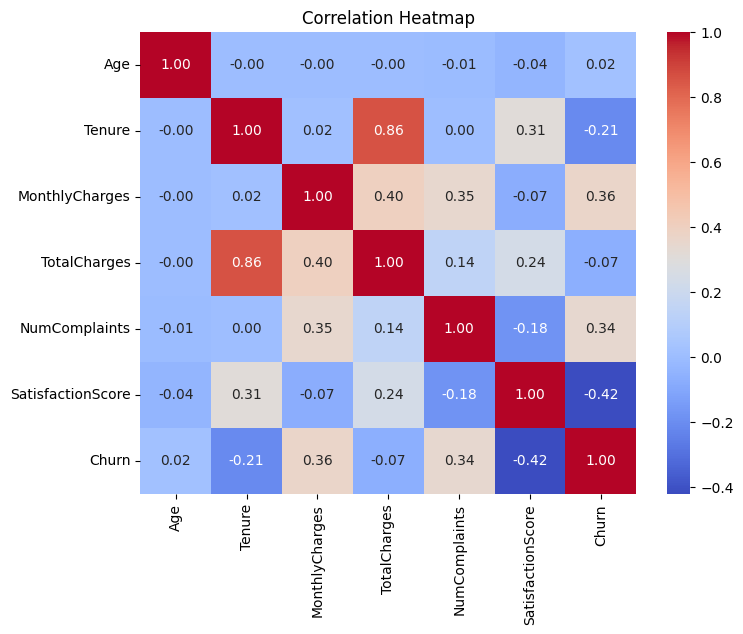

In [ ]:
# Correlation heatmap for numeric features
numeric_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
                 'NumComplaints', 'SatisfactionScore', 'Churn']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_549/300231731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ContractType', y='Churn', data=df, palette='Set3', errorbar=None)


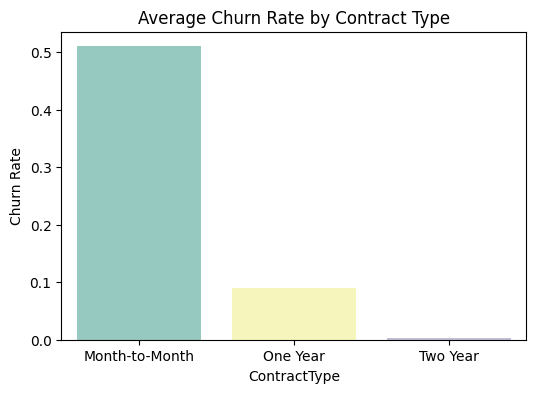

In [ ]:
# Churn rate by contract type — a classic churn driver
plt.figure(figsize=(6,4))
sns.barplot(x='ContractType', y='Churn', data=df, palette='Set3', errorbar=None)
plt.title('Average Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

In [ ]:
data = df.drop(columns=['CustomerID']).copy()

# Impute missing TotalCharges with the median
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# Binary categorical columns -> Label Encoding
binary_cols = ['Gender', 'TechSupport', 'OnlineSecurity', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# Multi-class categorical columns -> One-Hot Encoding
multi_cols = ['ContractType', 'InternetService', 'PaymentMethod']
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)

data.head()

,Gender,SeniorCitizen,Age,Tenure,TechSupport,OnlineSecurity,PaperlessBilling,MonthlyCharges,TotalCharges,NumComplaints,SatisfactionScore,Churn,ContractType_One Year,ContractType_Two Year,InternetService_Fiber Optic,InternetService_No,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,1,0,54,16,0,0,0,60.56,982.44,0,3.7,1,False,False,False,False,False,False,True
1,0,0,49,9,1,0,1,86.60,842.55,5,5.7,1,False,False,True,False,False,False,False
2,1,1,49,7,1,1,1,37.84,258.88,2,8.7,0,True,False,False,False,False,True,False
3,1,0,23,14,1,0,1,61.15,883.27,0,7.5,0,False,True,False,False,True,False,False
4,1,0,56,3,1,0,1,98.89,251.26,1,8.0,0,False,True,True,False,False,True,False


In [ ]:
X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Further split off a validation set from the training data (used by EarlyStopping)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)

Train: (1280, 18)  Val: (320, 18)  Test: (400, 18)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
n_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6422 - auc: 0.5715 - loss: 0.6311 - val_accuracy: 0.7000 - val_auc: 0.7025 - val_loss: 0.5779
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7203 - auc: 0.7498 - loss: 0.5407 - val_accuracy: 0.7406 - val_auc: 0.8648 - val_loss: 0.4813
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7469 - auc: 0.8289 - loss: 0.4816 - val_accuracy: 0.8125 - val_auc: 0.9155 - val_loss: 0.4148
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7969 - auc: 0.8652 - loss: 0.4340 - val_accuracy: 0.8719 - val_auc: 0.9385 - val_loss: 0.3561
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8391 - auc: 0.9121 - loss: 0.3690 - val_accuracy: 0.8844 - val_auc: 0.9493 - val_loss: 0.3024
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8562 - auc: 0.9223 - loss: 0.3344 - val_accuracy: 0.9031 - val_auc: 0.9576 - val_loss: 0.2639
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

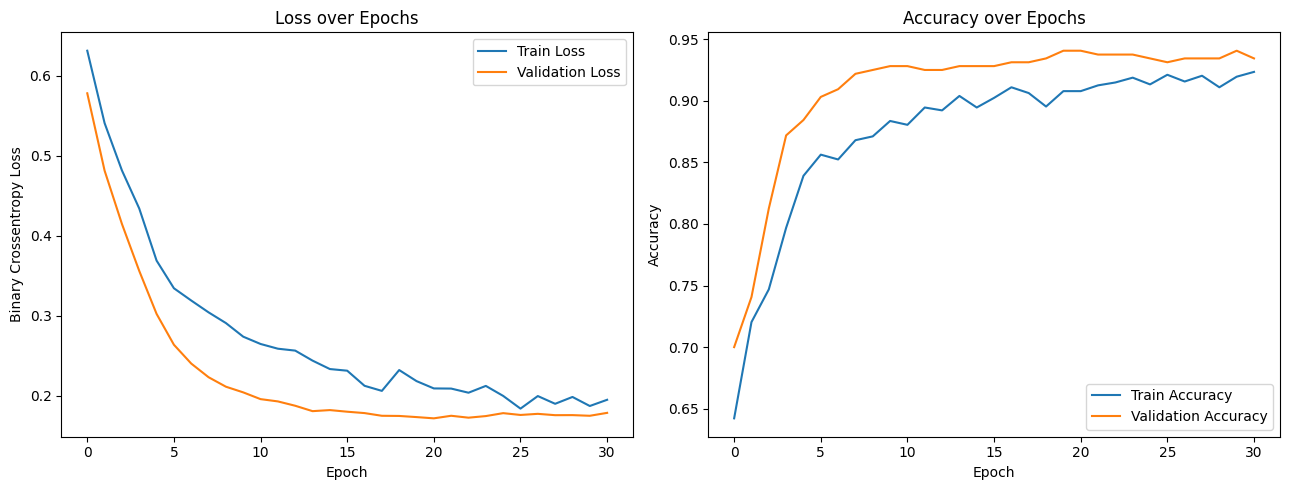

Training stopped at epoch 31 (EarlyStopping patience=10)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Training stopped at epoch {len(history.history['loss'])} "
      f"(EarlyStopping patience=10)")

In [ ]:
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test AUC:      {test_auc:.4f}')

Test Loss:     0.2116
Test Accuracy: 0.9000
Test AUC:      0.9703


In [ ]:
y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

    Retained       0.95      0.90      0.93       275
     Churned       0.80      0.90      0.85       125

    accuracy                           0.90       400
   macro avg       0.88      0.90      0.89       400
weighted avg       0.91      0.90      0.90       400



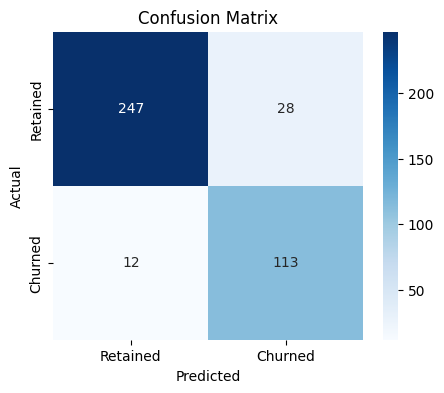

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

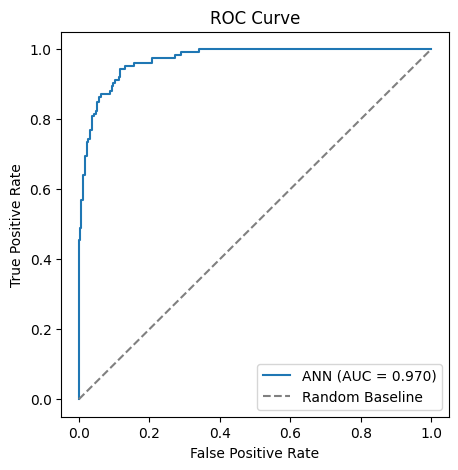

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
model.save('churn_ann_model.keras')
print('Model saved as churn_ann_model.keras')

# Optional: download to your local machine when running in Colab
# from google.colab import files
# files.download('churn_ann_model.keras')

Model saved as churn_ann_model.keras


In [ ]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
prob = model.predict(sample_scaled)[0][0]

print(f'Predicted churn probability: {prob:.2%}')
print(f'Predicted label: {"Churn" if prob >= 0.5 else "Retain"}')
print(f'Actual label: {"Churn" if y_test.iloc[0] == 1 else "Retain"}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted churn probability: 1.73%
Predicted label: Retain
Actual label: Retain
